# Bank Marketing Data Analysis
This notebook presents an analysis of the `bankmarketing.csv` dataset, which includes data related to a bank's marketing campaigns. The main goal is to understand customer behavior and predict whether a client will subscribe to a term deposit.

In [1]:

import pandas as pd

# Load the dataset
df = pd.read_csv('bankmarketing.csv')

# Display the first few rows
dataset = df.head()


In [2]:
dataset

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:

# Check for missing values and data types

# Checking the data types
dtypes = df.dtypes

# Check for missing values
missing = df.isnull().sum()

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Display the summary of the dataset
summary = pd.DataFrame({'Data Type': dtypes, 'Missing Values': missing, 'Missing %': (missing / len(df)) * 100})
print(f"Dataset Summary:\n{summary}")



Number of duplicate rows: 12
Dataset Summary:
               Data Type  Missing Values  Missing %
age                int64               0        0.0
job               object               0        0.0
marital           object               0        0.0
education         object               0        0.0
default           object               0        0.0
housing           object               0        0.0
loan              object               0        0.0
contact           object               0        0.0
month             object               0        0.0
day_of_week       object               0        0.0
duration           int64               0        0.0
campaign           int64               0        0.0
pdays              int64               0        0.0
previous           int64               0        0.0
poutcome          object               0        0.0
emp.var.rate     float64               0        0.0
cons.price.idx   float64               0        0.0
cons.conf.idx    f

In [7]:

# Summary statistics

df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


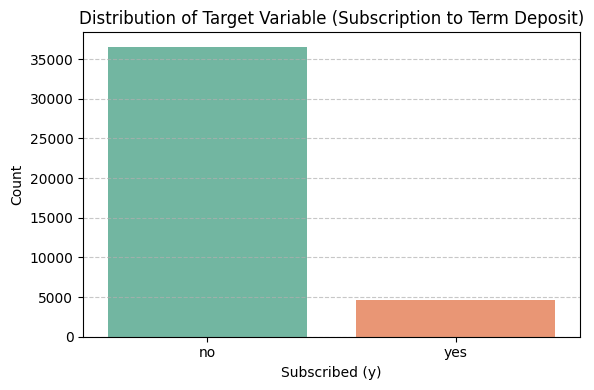

In [9]:

import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the target variable

# Plot the distribution of the target variable 'y'
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='y', hue='y', palette='Set2', legend=False)

plt.title('Distribution of Target Variable (Subscription to Term Deposit)')
plt.xlabel('Subscribed (y)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




In [14]:
# Calculate value counts and percentages
value_counts = df['y'].value_counts()
percentages = (value_counts / value_counts.sum() * 100).round(2)
# Create a DataFrame for the value counts and percentages
value_counts_df = pd.DataFrame({
    'Count': value_counts,
    'Percentage (%)': percentages
})
# Display the value counts and percentages
print("Value Counts and Percentages of Target Variable (y):\n", value_counts_df)

Value Counts and Percentages of Target Variable (y):
      Count  Percentage (%)
y                         
no   36548           88.73
yes   4640           11.27


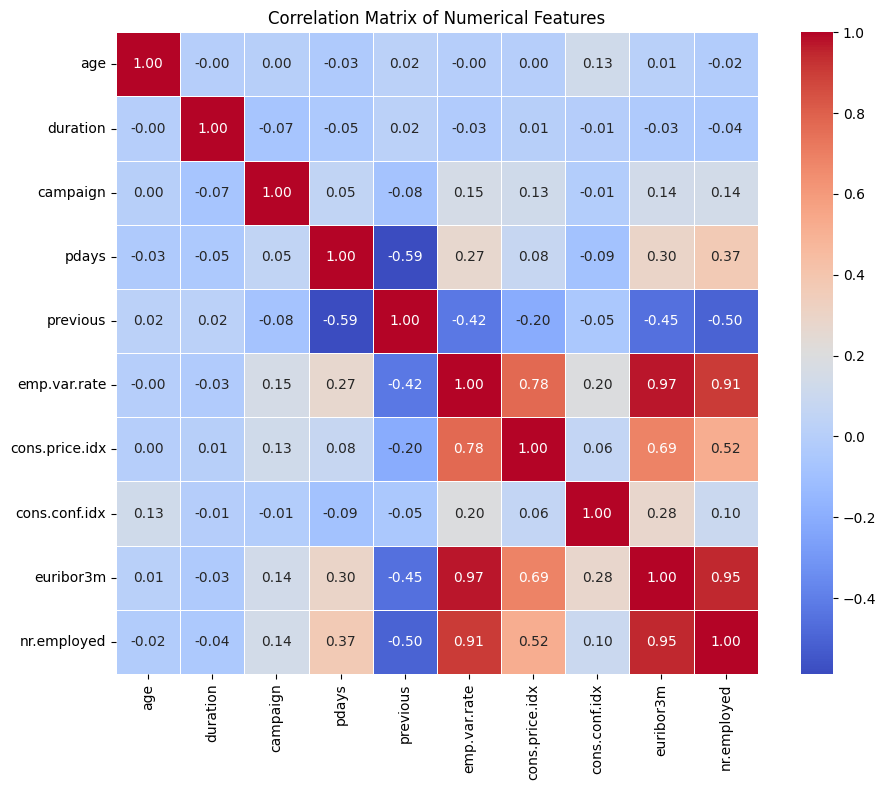

In [2]:

# Correlation matrix for numerical features

import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
correlation_matrix = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)

plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()



## Conclusion

In this analysis, we explored the structure and composition of the bank marketing dataset. Key takeaways include:

- The dataset includes customer demographics and contact details, which can be useful for segmentation.
- A majority of customers do not subscribe to term deposits, indicating an imbalanced dataset.
- Further preprocessing, feature engineering, and modeling would be the next steps for predictive analysis.

This initial inspection sets the foundation for a deeper analysis or machine learning workflow to improve marketing effectiveness.
